# Assam Government Procurement Intelligence Dashboard — 2016 to 2022

A summary of how public procurement money was spent across six fiscal years in Assam — where it went, how competitive the bidding was, and where it's most concentrated. Built from 34,232 tenders published by 101 government departments.

Each chart below is followed by a short, plain-English explanation of what it means. The underlying code is collapsed throughout, to keep the focus on the findings — the full working (SQL queries, data cleaning, and chart code) is in Notebooks 1–3.

*Source: Assam Finance Department via data.gov.in*

*(Setup — connects to the cleaned dataset and sets the shared chart style used throughout. Collapsed; expand if you want to see it.)*

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

PROJECT_ROOT = Path("..").resolve()
DB_PATH = PROJECT_ROOT / "db" / "assam_procurement.db"

TEAL = "#2a7b7b"
AMBER = "#e0a458"
RED = "#c0392b"
SOURCE_NOTE = "Source: Assam Finance Department via data.gov.in"

# Larger, presentation-scale defaults — this notebook is meant to be read, not coded in.
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.edgecolor"] = "#444444"
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


def add_source_note(fig):
    """Stamp the standard source annotation in the bottom-right of a chart."""
    fig.text(0.99, 0.01, SOURCE_NOTE, ha="right", va="bottom", fontsize=9, color="#666666")


conn = sqlite3.connect(DB_PATH)

## 1. Spending Over Time

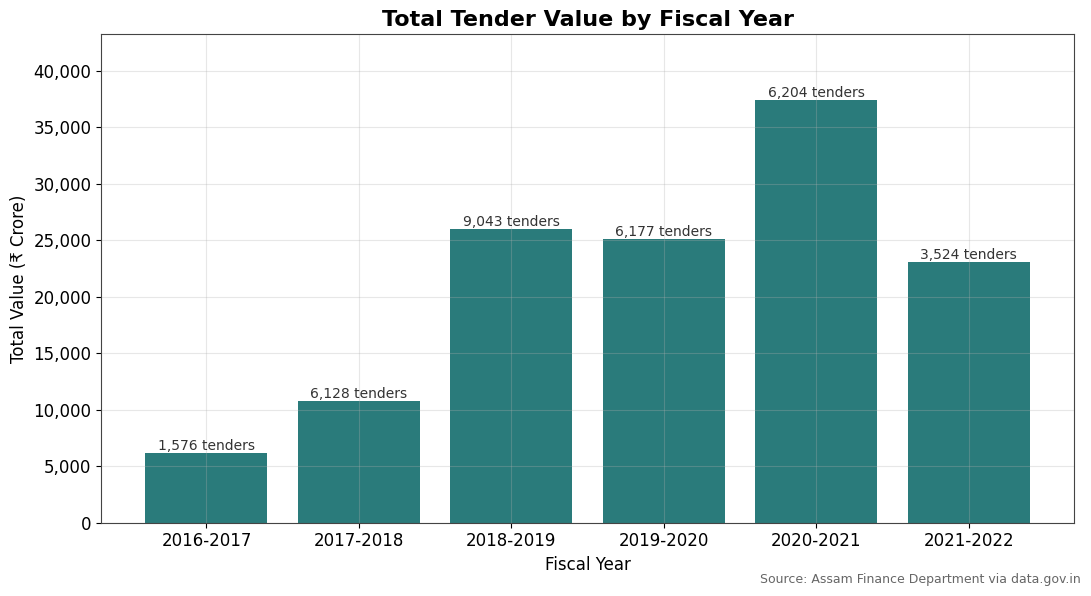

In [2]:
yearly_trend = pd.read_sql_query(
    """
    SELECT
        fiscal_year,
        COUNT(*) AS tender_count,
        SUM(value_crores) AS total_value_crores
    FROM tenders_clean
    WHERE value_crores IS NOT NULL
    GROUP BY fiscal_year
    ORDER BY fiscal_year;
    """,
    conn,
)

fig, ax = plt.subplots()
bars = ax.bar(yearly_trend["fiscal_year"], yearly_trend["total_value_crores"], color=TEAL)

for bar, count in zip(bars, yearly_trend["tender_count"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,} tenders",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#333333",
    )

ax.set_title("Total Tender Value by Fiscal Year")
ax.set_xlabel("Fiscal Year")
ax.set_ylabel("Total Value (₹ Crore)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.set_ylim(top=ax.get_ylim()[1] * 1.1)

add_source_note(fig)
plt.tight_layout()
plt.show()

Tender activity and tender spending don't peak in the same year. The *number* of tenders published peaked in 2018–19, but total *value* peaked two years later, in 2020–21, on a noticeably smaller count of tenders — meaning the average tender roughly doubled in size over that period. Recent growth in spending has come from a shrinking number of larger contracts, not from more procurement activity overall. Spending has eased since the 2020–21 peak but remains well above where it started in 2016–17.

## 2. Where the Money Goes — Department Spending

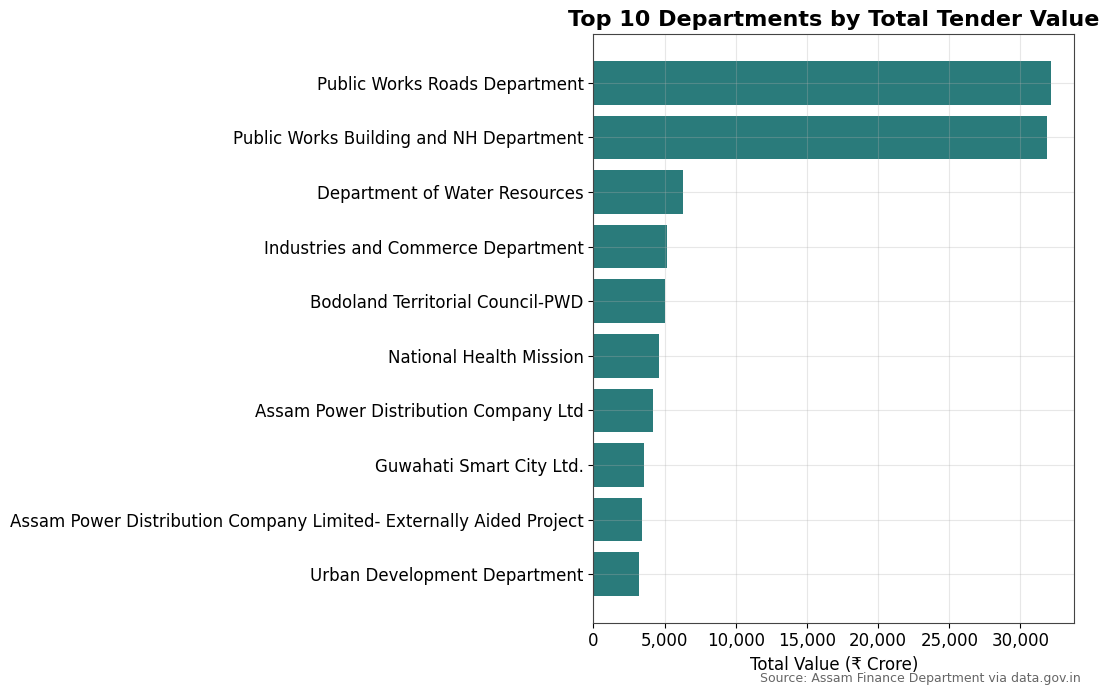

In [3]:
top_departments = pd.read_sql_query(
    """
    SELECT
        buyer_name,
        SUM(value_crores) AS total_value_crores
    FROM tenders_clean
    WHERE value_crores IS NOT NULL
    GROUP BY buyer_name
    ORDER BY total_value_crores DESC
    LIMIT 10;
    """,
    conn,
).sort_values("total_value_crores")

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(top_departments["buyer_name"], top_departments["total_value_crores"], color=TEAL)

ax.set_title("Top 10 Departments by Total Tender Value")
ax.set_xlabel("Total Value (₹ Crore)")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

add_source_note(fig)
plt.tight_layout()
plt.show()

Spending is heavily concentrated in just two departments. Public Works Roads Department and Public Works Building and NH Department together account for **roughly half of all tender value awarded across all 101 buyer departments** over the six years in this dataset. Every other department — including sizeable spenders like Water Resources and the National Health Mission — splits the remaining half between them. Because so much of the budget flows through just these two departments, procurement quality there has an outsized effect on overall spending outcomes for the state.

## 3. How Competitive Is Procurement?

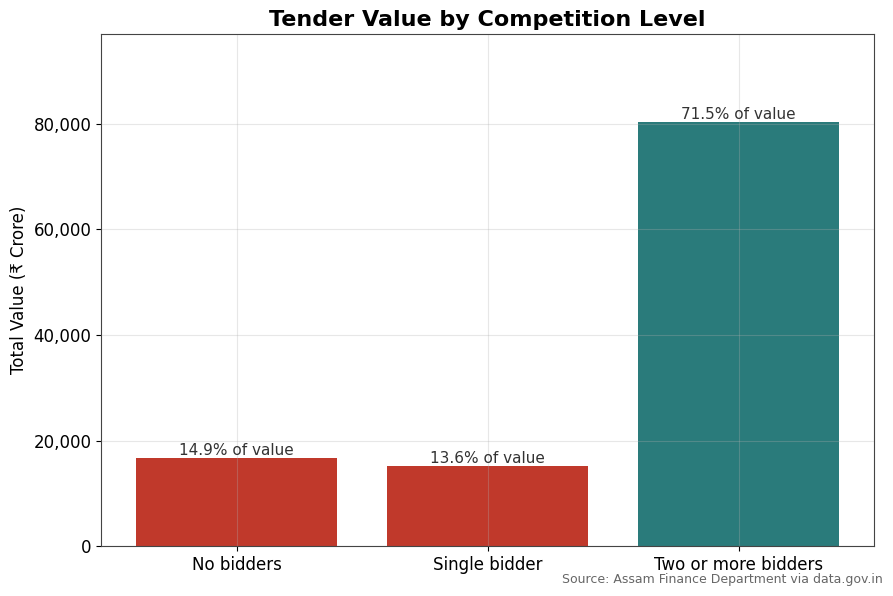

In [4]:
competition_summary = pd.read_sql_query(
    """
    SELECT
        CASE
            WHEN tender_numberOfTenderers = 0 THEN 'No bidders'
            WHEN tender_numberOfTenderers = 1 THEN 'Single bidder'
            ELSE 'Two or more bidders'
        END AS competition_group,
        SUM(value_crores) AS total_value_crores
    FROM tenders_clean
    WHERE tender_numberOfTenderers IS NOT NULL AND value_crores IS NOT NULL
    GROUP BY competition_group;
    """,
    conn,
)
competition_summary["pct_of_value"] = (
    100 * competition_summary["total_value_crores"] / competition_summary["total_value_crores"].sum()
)
group_order = ["No bidders", "Single bidder", "Two or more bidders"]
competition_summary = competition_summary.set_index("competition_group").reindex(group_order).reset_index()
group_colors = [RED, RED, TEAL]

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(competition_summary["competition_group"], competition_summary["total_value_crores"], color=group_colors)

for i, (value, pct) in enumerate(
    zip(competition_summary["total_value_crores"], competition_summary["pct_of_value"])
):
    ax.text(i, value, f"{pct:.1f}% of value", ha="center", va="bottom", fontsize=11, color="#333333")

ax.set_title("Tender Value by Competition Level")
ax.set_xlabel("")
ax.set_ylabel("Total Value (₹ Crore)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.set_ylim(top=ax.get_ylim()[1] * 1.15)

add_source_note(fig)
plt.tight_layout()
plt.show()

Weak or absent competition is far from a rare edge case. Tenders that received **no bidders at all**, and tenders that received **exactly one bidder**, together account for a substantial share of total spending — roughly **28% of all tender value** went out with no meaningful price competition behind it. A tender with no bidders had to be re-advertised or awarded some other way; a tender with one bidder faced no competitive pressure on price at all. Either way, that spending received markedly less market scrutiny than the majority of procurement, which attracted multiple bidders.

## 4. How Tenders Are Awarded

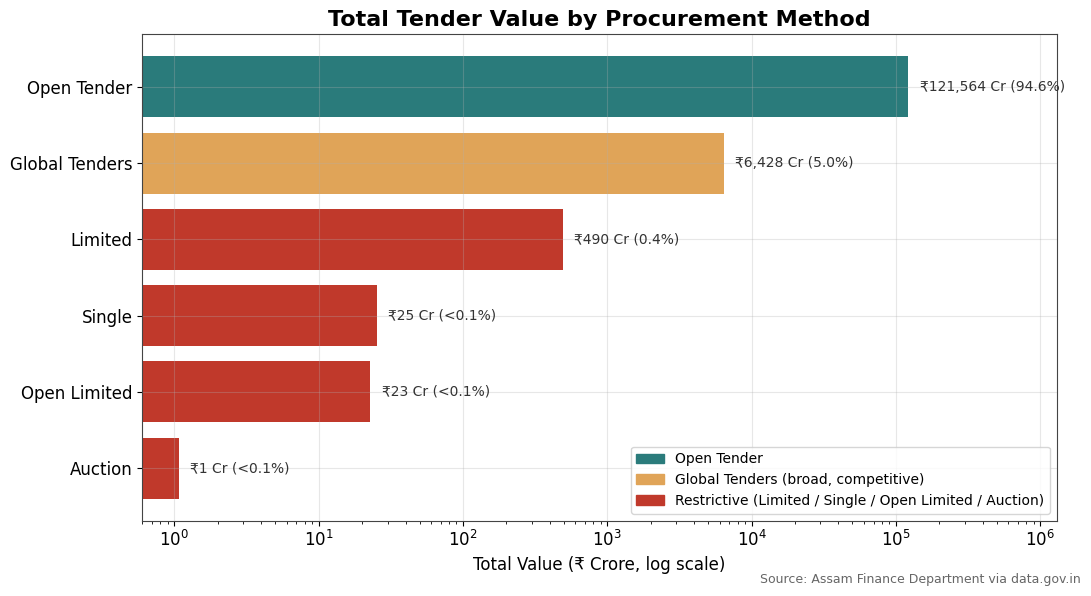

In [5]:
procurement_method = pd.read_sql_query(
    """
    SELECT
        tender_procurementMethod,
        SUM(value_crores) AS total_value_crores
    FROM tenders_clean
    WHERE value_crores IS NOT NULL
    GROUP BY tender_procurementMethod
    ORDER BY total_value_crores DESC;
    """,
    conn,
)
procurement_method["pct_of_value"] = (
    100 * procurement_method["total_value_crores"] / procurement_method["total_value_crores"].sum()
)


def method_color(method):
    if method == "Open Tender":
        return TEAL
    if method == "Global Tenders":
        return AMBER
    return RED


def format_pct(pct):
    return "<0.1%" if 0 < pct < 0.05 else f"{pct:.1f}%"


plot_data = procurement_method.sort_values("total_value_crores")
colors = [method_color(m) for m in plot_data["tender_procurementMethod"]]

fig, ax = plt.subplots()
bars = ax.barh(plot_data["tender_procurementMethod"], plot_data["total_value_crores"], color=colors)

for bar, value, pct in zip(bars, plot_data["total_value_crores"], plot_data["pct_of_value"]):
    ax.text(
        bar.get_width() * 1.2,
        bar.get_y() + bar.get_height() / 2,
        f"₹{value:,.0f} Cr ({format_pct(pct)})",
        va="center",
        fontsize=10,
        color="#333333",
    )

ax.set_title("Total Tender Value by Procurement Method")
ax.set_xlabel("Total Value (₹ Crore, log scale)")
ax.set_xscale("log")
ax.set_xlim(right=ax.get_xlim()[1] * 6)

legend_handles = [
    mpatches.Patch(color=TEAL, label="Open Tender"),
    mpatches.Patch(color=AMBER, label="Global Tenders (broad, competitive)"),
    mpatches.Patch(color=RED, label="Restrictive (Limited / Single / Open Limited / Auction)"),
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=10)

add_source_note(fig)
plt.tight_layout()
plt.show()

The vast majority of spending goes through genuinely competitive routes — about **95% via standard Open Tender**, plus another **5% via Global Tenders**, which opens bidding to international vendors and is just as competitive despite the different name. What's genuinely restrictive — Limited, Single-source, Open Limited, and Auction tenders combined — accounts for well under 1% of total value. That's a small share in percentage terms, but it's still real public money that bypassed competitive bidding entirely, and it's a short enough list to warrant a closer, tender-by-tender look rather than being dismissed as immaterial.

## 5. Where Spending Concentrates

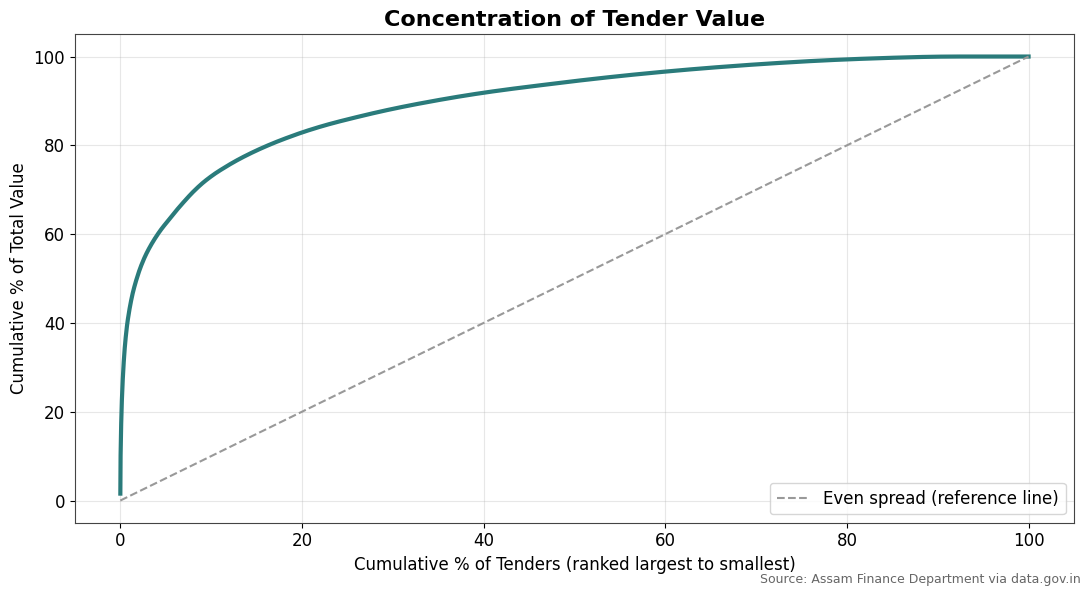

In [6]:
cumulative_share = pd.read_sql_query(
    """
    WITH ranked AS (
        SELECT
            value_crores,
            ROW_NUMBER() OVER (ORDER BY value_crores DESC) AS value_rank
        FROM tenders_clean
        WHERE value_crores IS NOT NULL
    )
    SELECT
        value_rank,
        SUM(value_crores) OVER (ORDER BY value_rank) AS cumulative_value_crores
    FROM ranked
    ORDER BY value_rank;
    """,
    conn,
)

total_value = cumulative_share["cumulative_value_crores"].iloc[-1]
n_tenders = len(cumulative_share)
cumulative_share["cumulative_pct"] = 100 * cumulative_share["cumulative_value_crores"] / total_value
cumulative_share["pct_of_tenders"] = 100 * cumulative_share["value_rank"] / n_tenders

top1_pct_value = cumulative_share.loc[
    cumulative_share["value_rank"] == round(n_tenders * 0.01), "cumulative_pct"
].iloc[0]

fig, ax = plt.subplots()
ax.plot(cumulative_share["pct_of_tenders"], cumulative_share["cumulative_pct"], color=TEAL, linewidth=3)
ax.plot([0, 100], [0, 100], color="#999999", linestyle="--", linewidth=1.5, label="Even spread (reference line)")

ax.set_title("Concentration of Tender Value")
ax.set_xlabel("Cumulative % of Tenders (ranked largest to smallest)")
ax.set_ylabel("Cumulative % of Total Value")
ax.legend(loc="lower right")

add_source_note(fig)
plt.tight_layout()
plt.show()

Spending is highly concentrated: the top 1% of tenders by value — just over 300 contracts out of 34,232 — account for **43% of all money spent**. The further the curve above bows away from the dashed reference line, the more concentrated spending is; here it bows sharply. In practical terms, getting the process right on a relatively short list of large tenders matters more to overall spending outcomes than the much longer tail of small, routine purchases — and that short list is where oversight effort is best spent.

---

**In short:** spending is growing in size per contract, concentrated in two departments and a small number of large tenders, and mostly — but not entirely — competitive. The exceptions (no/single-bidder tenders, restrictive procurement methods, and the largest individual contracts) are where the highest-value oversight would pay off.

*Source: Assam Finance Department via data.gov.in*

In [7]:
conn.close()